# 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\orams\Downloads\NEX AFRICA\WEEK 2\telco_churn_cleaned.csv')

In [4]:
df.describe(include='object')

C:\Users\orams\AppData\Local\Temp\ipykernel_8540\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


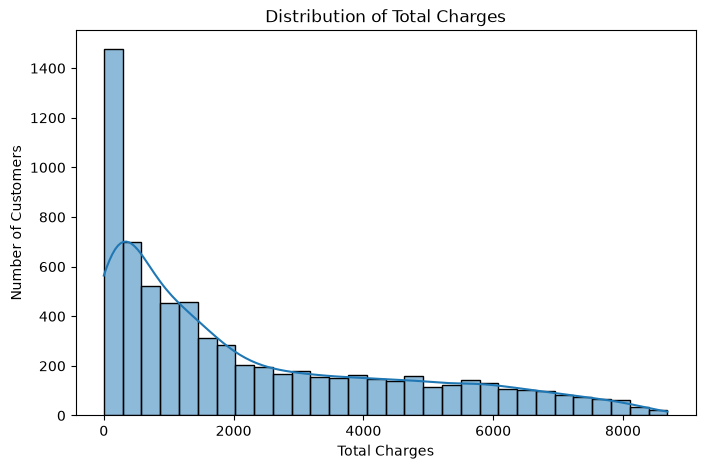

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')
plt.show()

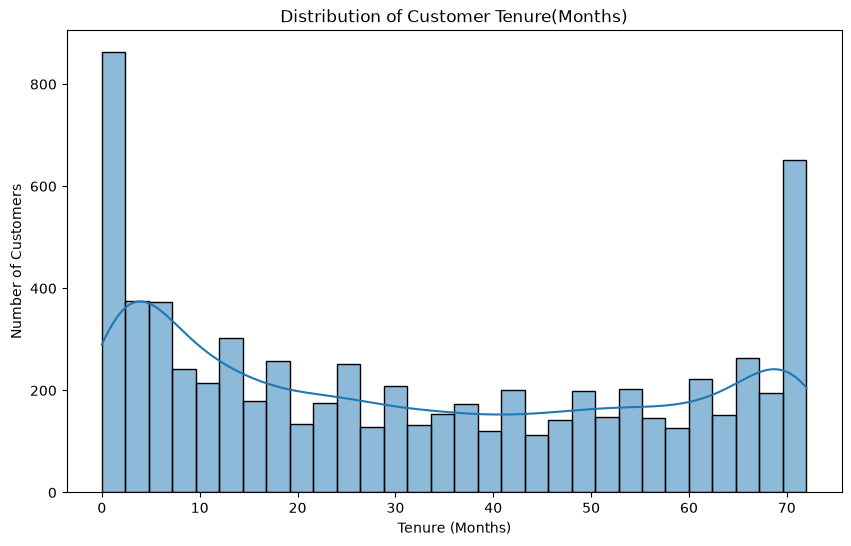

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Distribution of Customer Tenure(Months)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

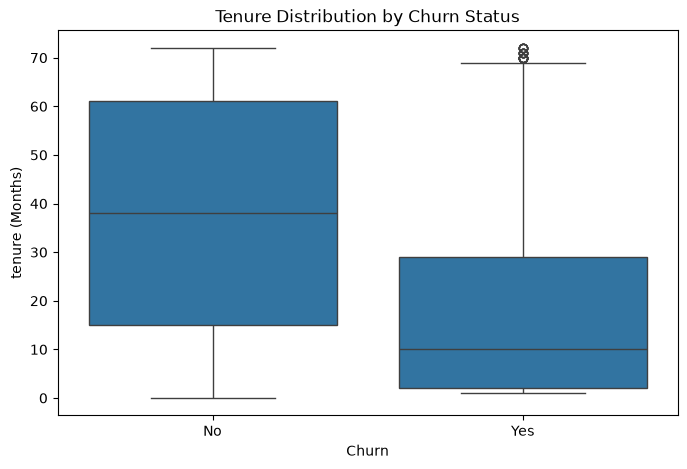

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('tenure (Months)')
plt.show()

Tenure and churn 1: Median tenure for churned customers is around 10 months versus 38 months for non-churned customers, confirming that newer customers are far more likely to leave

In [9]:
#CHURN BY CONTRACT TYPE

For comparing a categorical variable against Churn (also categorical), a grouped count plot is the standard tool, it shows the count of churned vs non-churned customers within each contract type, side by side.

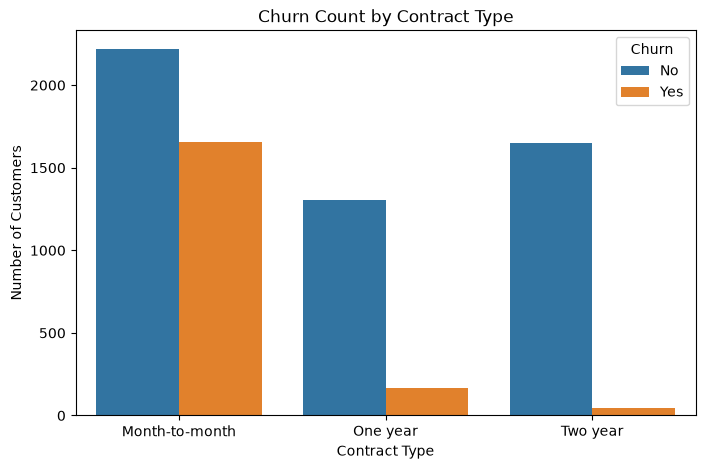

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn Count by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

In [11]:
#Getting the actual percentages
df.groupby('Contract')['Churn'].value_counts(normalize=True) * 100

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.730482
                Yes      11.269518
Two year        No       97.168142
                Yes       2.831858
Name: proportion, dtype: float64

Contract type and churn 2: Month-to-month customers churn at 42.7%, compared to 11.3% for one-year and 2.8% for two-year contracts, making contract type one of the strongest churn drivers in the dataset.

In [12]:
#CHURN BY PAYMENT METHOD

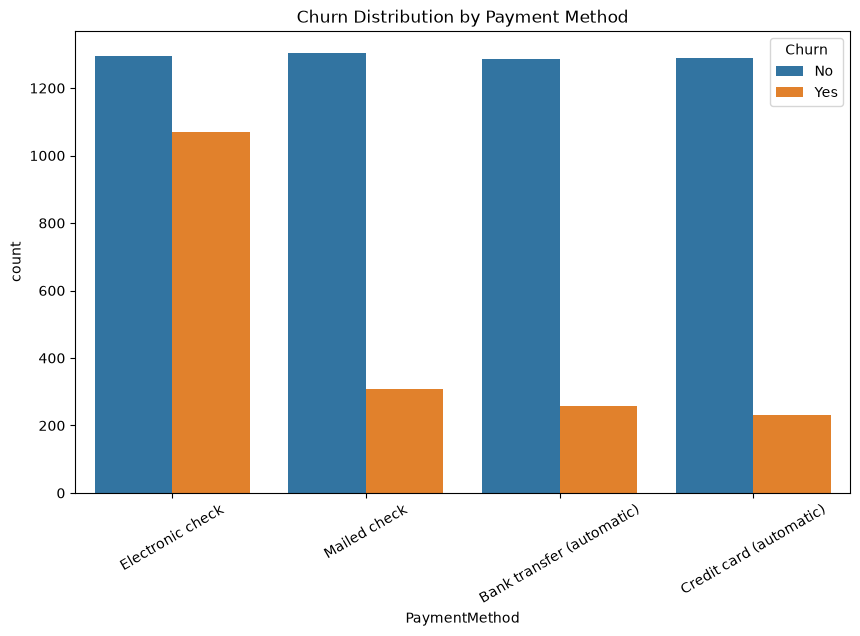

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn Distribution by Payment Method')
plt.xticks(rotation=30)
plt.show()

In [14]:
# Calculate the percentage breakdown of Churn within each Payment Method group
churn_payment_analysis = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).mul(100).unstack().fillna(0)
print(churn_payment_analysis)


Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


Payment method and churn 3: Electronic check users churn at 45.3%, more than double every other payment method (bank transfer 16.7%, credit card 15.2%, mailed check 19.1%), possibly due to recurring friction in manual, non-automatic payments. (Goes after your PaymentMethod count plot)

In [15]:
#Monthly Charges vs Churn

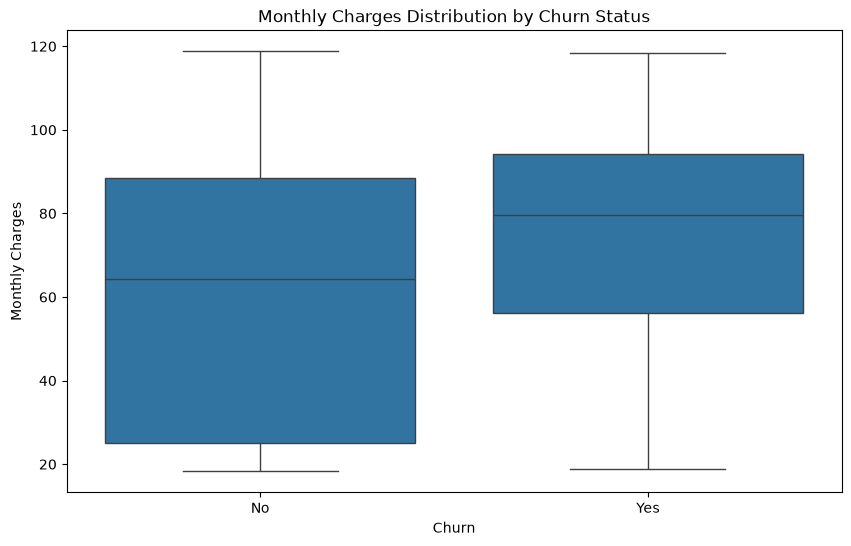

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

Monthly charges and churn 4: Churned customers have a higher median MonthlyCharges (around 79) than non-churned customers (around 64), suggesting price sensitivity or dissatisfaction with premium-tier pricing plays a role.

In [17]:
#InternetService vs Churn

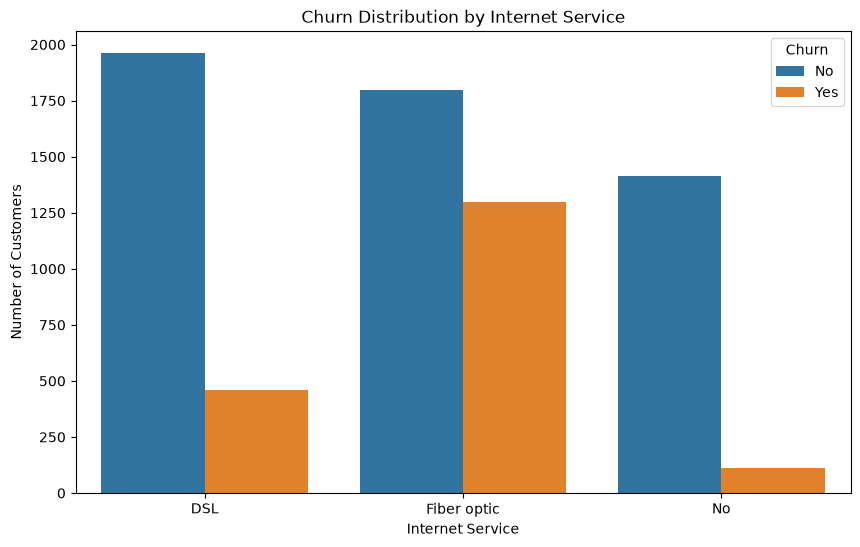

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn Distribution by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

In [19]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True).mul(100).unstack().fillna(0)

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


Internet service and churn 5: Fiber optic customers show the highest churn rate among internet service types at 41.9%, compared to 19.0% for DSL and 7.4% for customers with no internet service. This aligns with the earlier finding that higher MonthlyCharges correlates with higher churn, since fiber is typically the more expensive, premium internet tier. It may also reflect that fiber customers have higher service expectations (speed, reliability) and are quicker to leave if those aren't met, or that fiber is more available from competing providers, giving these customers more alternatives to switch to.

In [20]:
#Correlation Heatmap

A correlation heatmap instead shows how all your numeric variables relate to each other and to churn, all in a single view.

In [22]:
df['Churn_numeric'] = df['Churn'].map({'Yes':1, 'No':0})

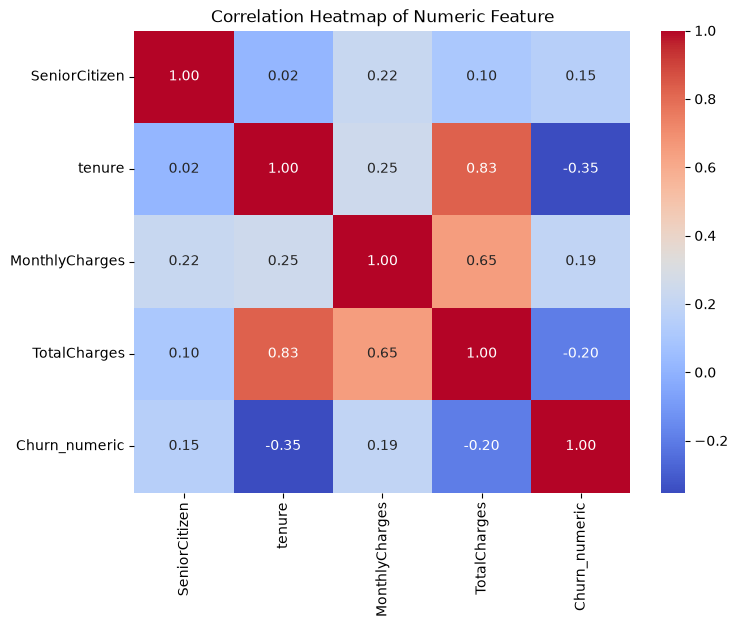

In [30]:
plt.figure(figsize=(8,6))
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Feature')
plt.show()



Numeric correlations with churn 6: Tenure has the strongest correlation with churn among numeric variables (-0.35), confirming that longer-tenured customers are meaningfully less likely to churn. MonthlyCharges shows a weaker positive correlation (0.19), and TotalCharges a weaker negative one (-0.20), both consistent with earlier findings, though none as strong as tenure's relationship.

In [31]:
#SENIORCITIZEN VS CHURN

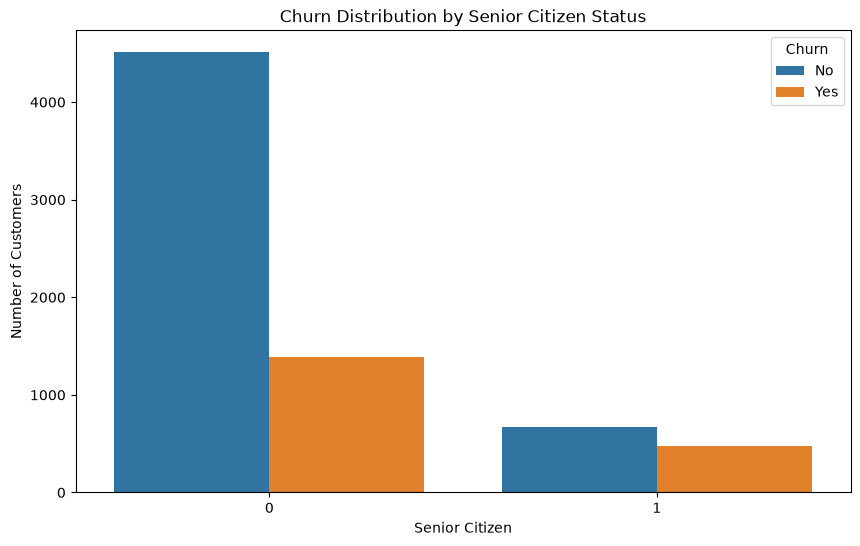

In [34]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.title('Churn Distribution by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Number of Customers')
plt.show()

In [36]:
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True)

SeniorCitizen  Churn
0              No       0.763938
               Yes      0.236062
1              No       0.583187
               Yes      0.416813
Name: proportion, dtype: float64

In [40]:
#compares every cell in those 8 columns to the string 'Yes'
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['NumServices'] = (df[service_cols] == 'Yes').sum(axis=1)

Senior citizens and churn 7: Senior citizens churn at nearly double the rate of non-seniors, 41.7% versus 23.6%, despite a relatively weak correlation coefficient, indicating this group may have distinct needs worth addressing separately

In [41]:
#Count services per customer

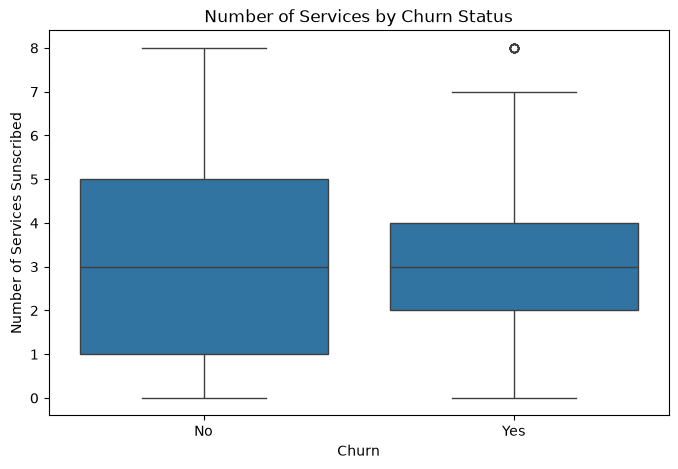

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='NumServices')
plt.title('Number of Services by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Number of Services Sunscribed')
plt.show()

Insight 8 (NumServices): The median number of subscribed services is the same for both churned and non-churned customers (3), though the non-churned group shows a slightly wider spread (interquartile range 1 to 5, max 8) compared to churned customers (interquartile range 2 to 4, max 7). This suggests raw service count alone is not a strong standalone predictor of churn, unlike tenure or contract type. It may be more useful combined with other features, or specific individual services may matter more than the total count.

In [45]:
#FEATURE 1: TENURE GROUPS

In [48]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 months'
    elif tenure <= 24:
        return '13-24 months'
    elif tenure <= 48:
        return '25-48 months'
    else:
        return '49-72 months'

In [49]:
df['TenureGroup'] = df['tenure'].apply(tenure_group)

In [50]:
#FEATURE 2 HasInternetService flag

In [51]:
df['HasInternetService'] = df['InternetService'].apply(lambda x: 'No' if x == 'No' else 'Yes')

In [53]:
#VERIFICATION 
df[['tenure', 'TenureGroup', 'InternetService', 'HasInternetService', 'NumServices']].head(10)

,tenure,TenureGroup,InternetService,HasInternetService,NumServices
0,1,0-12 months,DSL,Yes,1
1,34,25-48 months,DSL,Yes,3
2,2,0-12 months,DSL,Yes,3
3,45,25-48 months,DSL,Yes,3
4,2,0-12 months,Fiber optic,Yes,1
5,8,0-12 months,Fiber optic,Yes,5
6,22,13-24 months,Fiber optic,Yes,4
7,10,0-12 months,DSL,Yes,1
8,28,25-48 months,Fiber optic,Yes,6
9,62,49-72 months,DSL,Yes,3


In [54]:
#FEATURE PREPOCESSING

Dropping irrelevant columns

In [55]:
df_model = df.drop(columns=['customerID', 'Churn_numeric'])

customerID has zero predictive value, Churn_numeric was only a temporary helper column for the heatmap, we don't need a duplicate of the target hanging around

'Separating features (X) from target (y)

In [56]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

Encode categorical variables

In [58]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [60]:
#Scale numeric features
from sklearn.preprocessing import StandardScaler

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']
scaler = StandardScaler()
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

In [61]:
X_encoded.shape

(7043, 35)

In [62]:
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,NumServices,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24 months,TenureGroup_25-48 months,TenureGroup_49-72 months,HasInternetService_Yes
0,0,-1.277445,-1.160323,-0.992611,-1.145997,False,True,False,False,True,...,False,False,True,False,True,False,False,False,False,True
1,0,0.066327,-0.259629,-0.172165,-0.176011,True,False,False,True,False,...,True,False,False,False,False,True,False,True,False,True
2,0,-1.236724,-0.362660,-0.958066,-0.176011,True,False,False,True,False,...,False,False,True,False,False,True,False,False,False,True
3,0,0.514251,-0.746535,-0.193672,-0.176011,True,False,False,False,True,...,True,False,False,False,False,False,False,True,False,True
4,0,-1.236724,0.197365,-0.938874,-1.145997,False,False,False,True,False,...,False,False,True,False,True,False,False,False,False,True


In [63]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [65]:
#SAVING DATASET
X_encoded['Churn'] = y
X_encoded.to_csv('telco_churn_ml_ready.csv', index=False)

In [66]:
import os
print(os.path.exists('telco_churn_ml_ready.csv'))

True
